# Кейс 4: Регрессия по функциональным данным через линейные функционалы

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)

## 0. Данные - кусочно-гладкие функции

Каждая функция-наблюдение имеет вид:
$$x_i(t) = \alpha_i\,\mathbf{1}(t\in[0,0.3]) + \beta_i\,\mathbf{1}(t\in[0.3,0.7]) + \gamma_i\,\mathbf{1}(t\in[0.7,1]) + \varepsilon_i(t), \quad t\in[0,1]$$

где $\alpha_i,\beta_i,\gamma_i\sim\mathcal{N}(0,1)$ — случайные коэффициенты, $\varepsilon_i(t)$ — белый шум.

**Целевая переменная** задаётся линейным функционалом:
$$y_i = 2\int_0^1 x_i(t)\,\mathbf{1}(t\in[0.3,0.7])\,dt - \int_0^1 x_i(t)\,\mathbf{1}(t\in[0,0.3])\,dt + \eta_i$$

Для идеальных кусочно-постоянных функций: $y_i \approx 2\cdot 0.4\cdot\beta_i - 0.3\cdot\alpha_i + \eta_i$.

In [16]:
def synthetic_function(num_intervals, left_bound, right_bound, coef1, coef2, coef3, noise_std=0.1):
    t = np.linspace(left_bound, right_bound, num_intervals)
    noise = np.random.normal(0, noise_std, size=t.shape)
    x = (coef1 * (t <= 0.3).astype(float)
         + coef2 * ((t > 0.3) & (t <= 0.7)).astype(float)
         + coef3 * (t > 0.7).astype(float)
         + noise)
    return x

def generate_synthetic_dataset(n_samples, left_bound, right_bound, n_points=100, noise_std=0.1):
    t = np.linspace(left_bound, right_bound, n_points)
    X = []
    coeffs = []
    for _ in range(n_samples):
        coef1, coef2, coef3 = np.random.randn(3)
        x = synthetic_function(n_points, left_bound, right_bound, coef1, coef2, coef3, noise_std)
        X.append(x)
        coeffs.append((coef1, coef2, coef3))
    return np.array(X), t, np.array(coeffs)

def compute_targets(X, t, noise_std=0.05):
    dt = t[1] - t[0]
    phi1 = ((t >= 0.3) & (t <= 0.7)).astype(float)
    phi2 = (t < 0.3).astype(float)
    y = 2.0 * (X @ phi1) * dt - (X @ phi2) * dt
    y += np.random.normal(0, noise_std, size=y.shape)
    return y

a, b = 0.0, 1.0
n_points = 100
n_train, n_test = 300, 100

X_all, t, coeffs_all = generate_synthetic_dataset(n_train + n_test, a, b, n_points)
y_all = compute_targets(X_all, t)
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=n_test, random_state=42)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")

X_train: (300, 100), y_train: (300,)
X_test:  (100, 100),  y_test:  (100,)


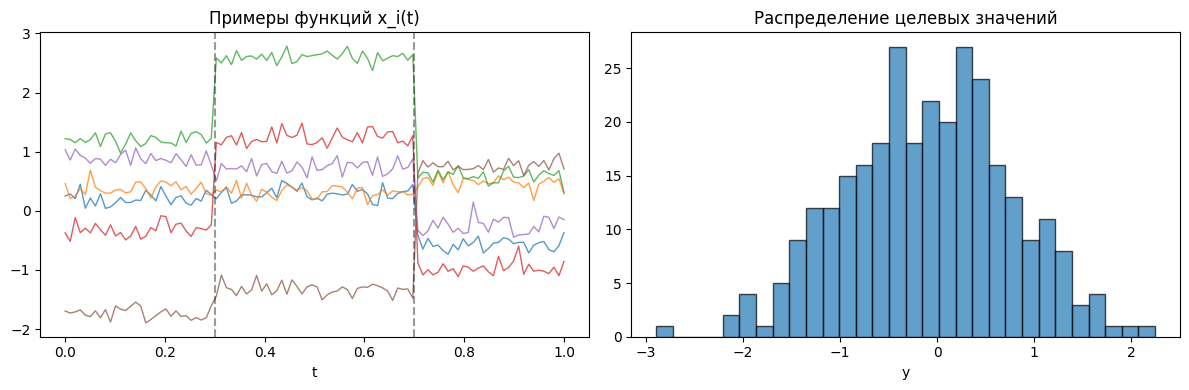

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i in range(6):
    axes[0].plot(t, X_train[i], alpha=0.75, linewidth=1)
axes[0].axvline(0.3, color='k', linestyle='--', alpha=0.4)
axes[0].axvline(0.7, color='k', linestyle='--', alpha=0.4)
axes[0].set_xlabel('t')
axes[0].set_title('Примеры функций x_i(t)')

axes[1].hist(y_train, bins=30, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('y')
axes[1].set_title('Распределение целевых значений')
plt.tight_layout()
plt.show()

## Задание 1. Пространство функций

Рассматривается пространство $L_2[0,1]$ со скалярным произведением:
$$\langle f, g\rangle = \int_0^1 f(t)\,g(t)\,dt$$

**Равномерная сетка:** $t_j = j/(n-1)$, $j=0,\ldots,n-1$, шаг $\Delta t = 1/(n-1)$.

Каждая функция хранится как вектор значений $\mathbf{x}_i = (x_i(t_0),\ldots,x_i(t_{n-1}))\in\mathbb{R}^n$.

**Численное интегрирование** методом прямоугольников (достаточно для равномерной сетки, ошибка $O(\Delta t)$):
$$\int_0^1 f(t)\,dt \approx \Delta t\sum_{j=0}^{n-1} f(t_j)$$

Метод трапеций даёт ошибку $O(\Delta t^2)$; для больших $n$ оба метода практически совпадают.

In [18]:
dt = t[1] - t[0]
print(f"Интервал: [{a}, {b}], n={n_points}, dt={dt:.4f}")

f1 = np.sin(2 * np.pi * t)
print(f"int sin(2pi t) dt: прямоугольники={np.sum(f1)*dt:.6f}, трапеции={trapezoid(f1,t):.6f}, точно=0")

f2 = t**2
print(f"int t^2 dt: прямоугольники={np.sum(f2)*dt:.6f}, точно={1/3:.6f}")

Интервал: [0.0, 1.0], n=100, dt=0.0101
int sin(2pi t) dt: прямоугольники=-0.000000, трапеции=-0.000000, точно=0
int t^2 dt: прямоугольники=0.338401, точно=0.333333


## Задание 2. Система линейных функционалов

### 2.1 Линейность интегрального функционала

Для любых $\alpha,\beta\in\mathbb{R}$ и $x,y\in L_2[a,b]$:
$$L_\phi(\alpha x + \beta y) = \int_a^b(\alpha x(t)+\beta y(t))\phi(t)\,dt = \alpha\int_a^b x(t)\phi(t)\,dt + \beta\int_a^b y(t)\phi(t)\,dt = \alpha L_\phi(x)+\beta L_\phi(y)$$

Линейность следует из линейности интеграла. По теореме Рисса–Фреше любой ограниченный линейный функционал на $L_2[a,b]$ имеет вид $L_\phi(x)=\langle x,\phi\rangle$ для единственного $\phi\in L_2[a,b]$.

### 2.2 Рассматриваемые системы

**1. Индикаторная система** (ортонормированная, $m$ равных подотрезков):
$$\phi_k(t) = \sqrt{m}\cdot\mathbf{1}\!\left(t\in\left[\tfrac{k-1}{m},\tfrac{k}{m}\right)\right), \quad k=1,\ldots,m$$

$L_{\phi_k}(x)=\sqrt{m}\int_{(k-1)/m}^{k/m}x(t)\,dt$ — нормированное среднее на $k$-м подотрезке.

Ортонормированность: $\langle\phi_k,\phi_k\rangle = m\cdot\tfrac{1}{m}=1$; $\langle\phi_k,\phi_l\rangle=0$ при $k\neq l$.

**2. Тригонометрическая система** (ортонормированный базис Фурье на $[0,1]$):
$$\phi_0=1,\quad \phi_{2k-1}(t)=\sqrt{2}\sin(2\pi kt),\quad \phi_{2k}(t)=\sqrt{2}\cos(2\pi kt),\quad k=1,2,\ldots$$

$L_{\phi_{2k-1}}(x)=\sqrt{2}\int_0^1 x(t)\sin(2\pi kt)\,dt$ — $k$-й синусоидальный коэффициент Фурье (с весом $\sqrt{2}$).

Ортонормированность: $\langle\phi_{2k-1},\phi_{2k-1}\rangle=2\int_0^1\sin^2(2\pi kt)\,dt=1$; $\langle\phi_{2k-1},\phi_{2k}\rangle=\int_0^1\sin(4\pi kt)\,dt=0$.

**3. Полиномиальная система** (не ортогональна):
$$\phi_k(t)=t^{k-1},\quad k=1,\ldots,m$$

$L_{\phi_k}(x)=\int_0^1 x(t)\,t^{k-1}\,dt$ — $(k-1)$-й момент функции. Система линейно независима, но не ортогональна.

In [19]:
def indicator_basis(t, m, normalize=True):
    breakpoints = np.linspace(t[0], t[-1], m + 1)
    basis = []
    for k in range(m):
        if k < m - 1:
            mask = (t >= breakpoints[k]) & (t < breakpoints[k + 1])
        else:
            mask = (t >= breakpoints[k]) & (t <= breakpoints[k + 1])
        phi = mask.astype(float)
        if normalize:
            phi = phi * np.sqrt(m)
        basis.append(phi)
    return np.array(basis)

def trig_basis(t, m):
    basis = [np.ones(len(t))]
    freq = 1
    while len(basis) < m:
        basis.append(np.sqrt(2) * np.sin(2 * np.pi * freq * t))
        if len(basis) < m:
            basis.append(np.sqrt(2) * np.cos(2 * np.pi * freq * t))
        freq += 1
    return np.array(basis[:m])

def poly_basis(t, m):
    return np.array([t**k for k in range(m)])

def gram_matrix(basis, t):
    dt = t[1] - t[0]
    return basis @ basis.T * dt

m_check = 5
G_ind  = gram_matrix(indicator_basis(t, m_check), t)
G_trig = gram_matrix(trig_basis(t, m_check), t)
G_poly = gram_matrix(poly_basis(t, m_check), t)

print("Отклонение от E (||G - I||_F):")
for G, name in zip([G_ind, G_trig, G_poly],
                   ['Индикаторная', 'Тригонометрическая', 'Полиномиальная']):
    print(f"  {name}: {np.linalg.norm(G - np.eye(m_check)):.2e}")

Отклонение от E (||G - I||_F):
  Индикаторная: 2.26e-02
  Тригонометрическая: 5.05e-02
  Полиномиальная: 1.98e+00


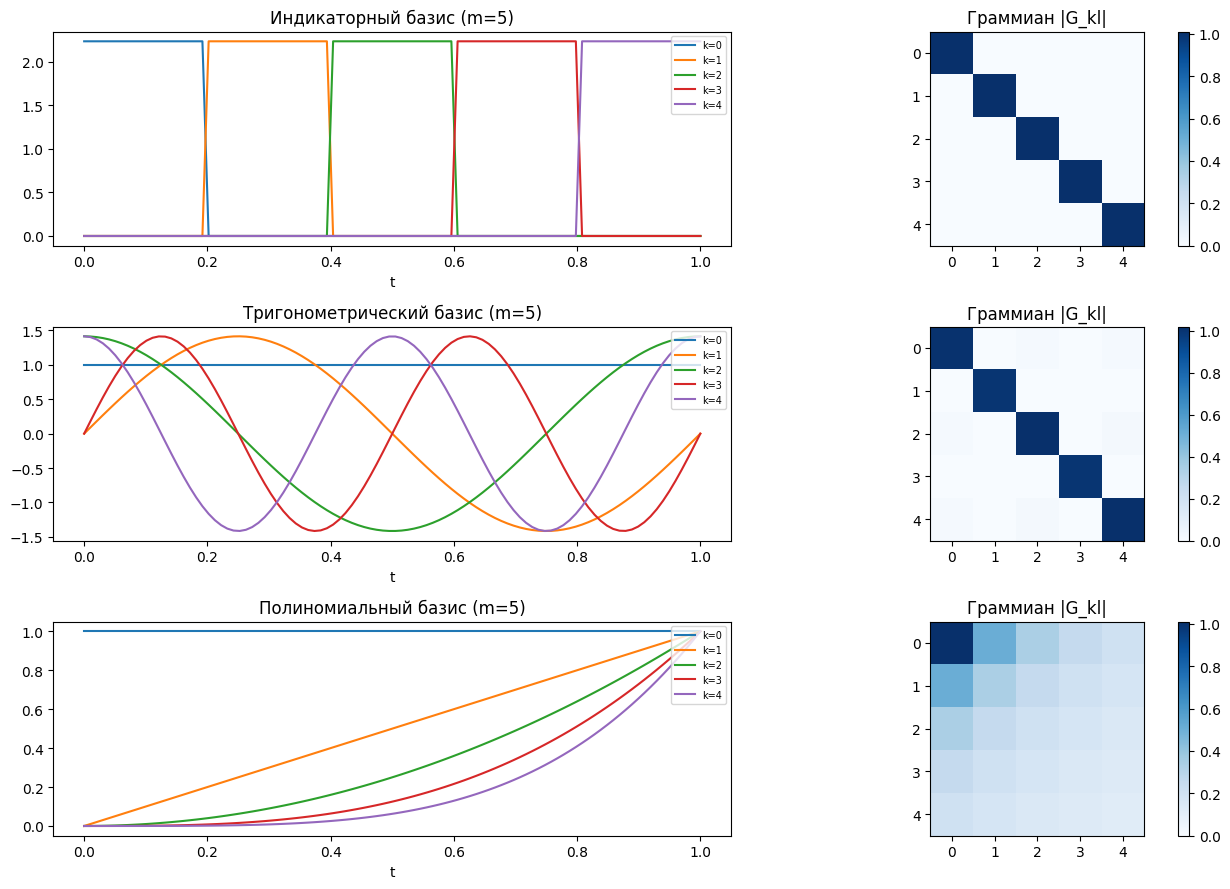

In [20]:
fig, axes = plt.subplots(3, 2, figsize=(13, 9))
bases_info = [
    (indicator_basis(t, m_check), G_ind,  'Индикаторный'),
    (trig_basis(t, m_check),      G_trig, 'Тригонометрический'),
    (poly_basis(t, m_check),      G_poly, 'Полиномиальный'),
]

for row, (basis, G, name) in enumerate(bases_info):
    ax_func, ax_gram = axes[row]
    for k, phi in enumerate(basis):
        ax_func.plot(t, phi, label=f'k={k}', linewidth=1.5)
    ax_func.set_title(f'{name} базис (m={m_check})')
    ax_func.legend(fontsize=7, loc='upper right')
    ax_func.set_xlabel('t')
    im = ax_gram.imshow(np.abs(G), cmap='Blues', vmin=0)
    ax_gram.set_title(f'Граммиан |G_kl|')
    plt.colorbar(im, ax=ax_gram)

plt.tight_layout()
plt.show()

## Задание 3. Линейная модель МНК

### 3a. Матричная форма

Введём матрицу признаков $\mathbf{Z}\in\mathbb{R}^{n\times(m+1)}$:
$$Z_{i,0}=1,\quad Z_{i,k}=z_{ik}=\int_a^b x_i(t)\phi_k(t)\,dt,\quad k=1,\ldots,m$$

Модель: $\hat{\mathbf{y}}=\mathbf{Z}\hat{\boldsymbol\beta}$, $\hat{\boldsymbol\beta}=(\hat\beta_0,\hat\beta_1,\ldots,\hat\beta_m)^\top$.

### 3b. Функционал МНК

$$Q(\boldsymbol\beta) = \|\mathbf{y}-\mathbf{Z}\boldsymbol\beta\|^2 = (\mathbf{y}-\mathbf{Z}\boldsymbol\beta)^\top(\mathbf{y}-\mathbf{Z}\boldsymbol\beta)$$

### 3c. Нормальные уравнения

Раскрываем:
$$Q(\boldsymbol\beta) = \mathbf{y}^\top\mathbf{y} - 2\boldsymbol\beta^\top\mathbf{Z}^\top\mathbf{y} + \boldsymbol\beta^\top\mathbf{Z}^\top\mathbf{Z}\boldsymbol\beta$$

Берём градиент и приравниваем нулю:
$$\nabla_{\boldsymbol\beta}Q = -2\mathbf{Z}^\top\mathbf{y} + 2\mathbf{Z}^\top\mathbf{Z}\boldsymbol\beta = 0 \implies \mathbf{Z}^\top\mathbf{Z}\hat{\boldsymbol\beta} = \mathbf{Z}^\top\mathbf{y}$$

### 3d. Формула решения

При условии $\det(\mathbf{Z}^\top\mathbf{Z})\neq 0$:
$$\hat{\boldsymbol\beta} = (\mathbf{Z}^\top\mathbf{Z})^{-1}\mathbf{Z}^\top\mathbf{y}$$

Матрица $\mathbf{Z}^\top\mathbf{Z}$ обратима тогда и только тогда, когда столбцы $\mathbf{Z}$ линейно независимы, что выполнено при $n>m+1$ и ненулевых сингулярных числах $\mathbf{Z}$.

In [21]:
def compute_feature_matrix(X, t, basis_funcs):
    dt = t[1] - t[0]
    Z = X @ basis_funcs.T * dt
    return np.hstack([np.ones((Z.shape[0], 1)), Z])

def ols_fit(Z, y):
    beta, _, _, _ = np.linalg.lstsq(Z, y, rcond=None)
    return beta

def ridge_fit(Z, y, lam):
    p = Z.shape[1]
    return np.linalg.solve(Z.T @ Z + lam * np.eye(p), Z.T @ y)

def eval_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {'MSE': mse, 'RMSE': np.sqrt(mse), 'R2': r2_score(y_true, y_pred)}

m = 10
Phi_ind  = indicator_basis(t, m)
Phi_trig = trig_basis(t, m)

Z_tr_ind  = compute_feature_matrix(X_train, t, Phi_ind)
Z_te_ind  = compute_feature_matrix(X_test,  t, Phi_ind)
Z_tr_trig = compute_feature_matrix(X_train, t, Phi_trig)
Z_te_trig = compute_feature_matrix(X_test,  t, Phi_trig)

beta_ind  = ols_fit(Z_tr_ind,  y_train)
beta_trig = ols_fit(Z_tr_trig, y_train)

for name, Z_tr, Z_te, beta in [
    ('Индикаторная',      Z_tr_ind,  Z_te_ind,  beta_ind),
    ('Тригонометрическая', Z_tr_trig, Z_te_trig, beta_trig),
]:
    tr = eval_metrics(y_train, Z_tr @ beta)
    te = eval_metrics(y_test,  Z_te @ beta)
    print(f"{name} (m={m}):")
    print(f"  Train: MSE={tr['MSE']:.4f}  RMSE={tr['RMSE']:.4f}  R2={tr['R2']:.4f}")
    print(f"  Test:  MSE={te['MSE']:.4f}  RMSE={te['RMSE']:.4f}  R2={te['R2']:.4f}")

Индикаторная (m=10):
  Train: MSE=0.0024  RMSE=0.0495  R2=0.9966
  Test:  MSE=0.0025  RMSE=0.0501  R2=0.9965
Тригонометрическая (m=10):
  Train: MSE=0.0025  RMSE=0.0504  R2=0.9965
  Test:  MSE=0.0026  RMSE=0.0515  R2=0.9963


## Задание 4. Функция весов $w(t)$

### 4.0 Доказательство равенства

По линейности интеграла (конечную сумму можно вносить под знак интеграла):
$$\sum_{k=1}^m\beta_k\langle x,\phi_k\rangle = \sum_{k=1}^m\beta_k\int_a^b x(t)\phi_k(t)\,dt = \int_a^b x(t)\sum_{k=1}^m\beta_k\phi_k(t)\,dt = \left\langle x,\sum_{k=1}^m\beta_k\phi_k\right\rangle$$

Перестановка конечной суммы и интеграла законна (интеграл линеен).

### 4.1 Функция весов

$$w(t) = \sum_{k=1}^m\hat\beta_k\phi_k(t)$$

Модель принимает компактный вид:
$$\hat{y}(x) = \hat\beta_0 + \langle x,w\rangle = \hat\beta_0 + \int_0^1 x(t)\,w(t)\,dt$$

Функция $w(t)$ — это свёртка вектора коэффициентов $\hat{\boldsymbol\beta}_{1:m}$ с базисными функциями. Она задаёт направление в $L_2[0,1]$, вдоль которого проецируется каждое наблюдение.

Проверка: max |y_pred_direct - y_pred_via_w|
  Индикаторная:       4.44e-16
  Тригонометрическая: 8.88e-16


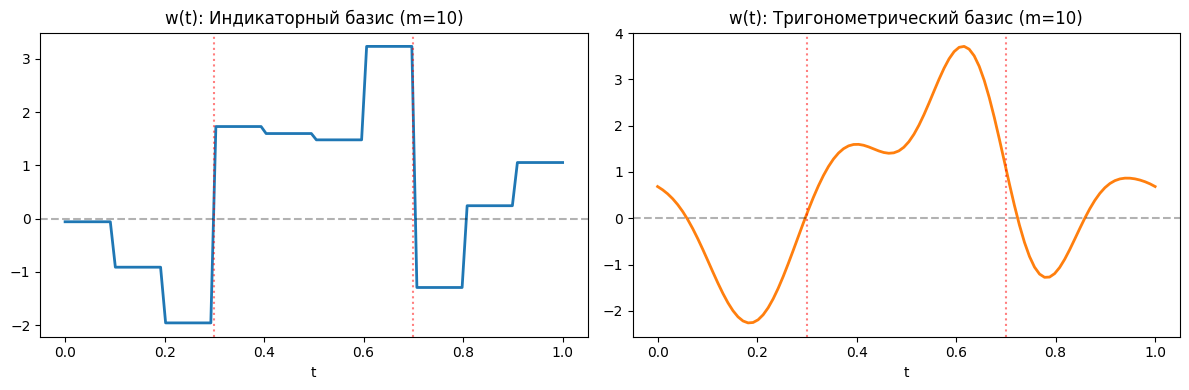

In [22]:
def weight_function(beta, basis_funcs):
    return basis_funcs.T @ beta[1:]

w_ind  = weight_function(beta_ind,  Phi_ind)
w_trig = weight_function(beta_trig, Phi_trig)

dt = t[1] - t[0]
y_via_w_ind  = beta_ind[0]  + X_test @ w_ind  * dt
y_via_w_trig = beta_trig[0] + X_test @ w_trig * dt
print("Проверка: max |y_pred_direct - y_pred_via_w|")
print(f"  Индикаторная:       {np.max(np.abs(y_via_w_ind  - Z_te_ind  @ beta_ind)):.2e}")
print(f"  Тригонометрическая: {np.max(np.abs(y_via_w_trig - Z_te_trig @ beta_trig)):.2e}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, w, name, color in zip(axes,
    [w_ind, w_trig],
    ['Индикаторный базис', 'Тригонометрический базис'],
    ['tab:blue', 'tab:orange']):
    ax.plot(t, w, color=color, linewidth=2)
    ax.axhline(0, color='k', linestyle='--', alpha=0.3)
    ax.axvline(0.3, color='r', linestyle=':', alpha=0.5)
    ax.axvline(0.7, color='r', linestyle=':', alpha=0.5)
    ax.set_title(f'w(t): {name} (m={m})')
    ax.set_xlabel('t')
plt.tight_layout()
plt.show()

## Задание 5. Сравнение наборов функционалов

Сравниваем три системы при фиксированном $m=10$: индикаторную, тригонометрическую и полиномиальную.

Индикаторная:
  Train: MSE=0.0024  RMSE=0.0495  R2=0.9966
  Test:  MSE=0.0025  RMSE=0.0501  R2=0.9965
  ||beta[1:]||_2 = 1.6036
Тригонометрическая:
  Train: MSE=0.0025  RMSE=0.0504  R2=0.9965
  Test:  MSE=0.0026  RMSE=0.0515  R2=0.9963
  ||beta[1:]||_2 = 1.6615
Полиномиальная:
  Train: MSE=0.0025  RMSE=0.0502  R2=0.9965
  Test:  MSE=0.0026  RMSE=0.0511  R2=0.9963
  ||beta[1:]||_2 = 1510565.3568


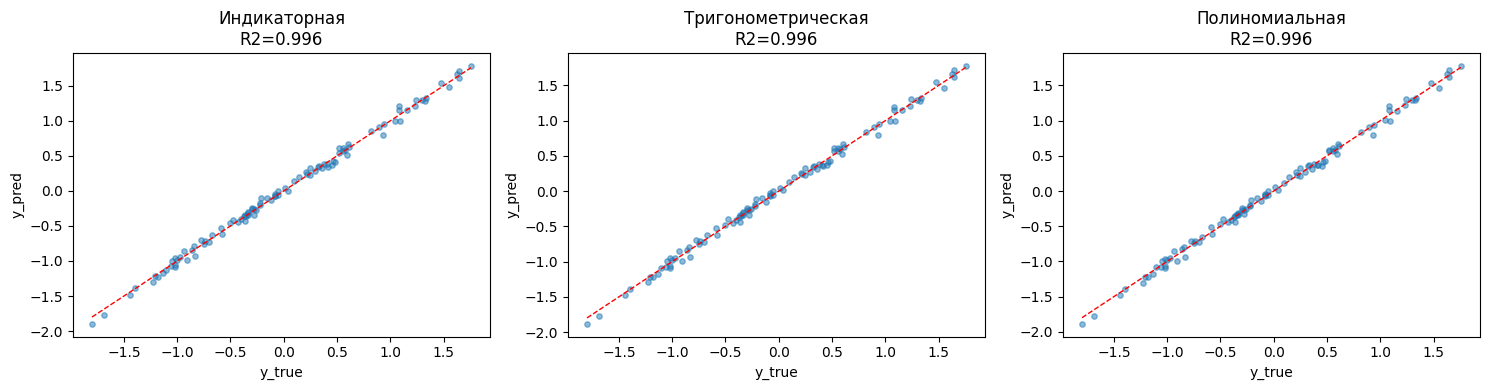

In [23]:
m = 10
bases = {
    'Индикаторная':      indicator_basis(t, m),
    'Тригонометрическая': trig_basis(t, m),
    'Полиномиальная':    poly_basis(t, m),
}

results = {}
for name, Phi in bases.items():
    Z_tr = compute_feature_matrix(X_train, t, Phi)
    Z_te = compute_feature_matrix(X_test,  t, Phi)
    beta = ols_fit(Z_tr, y_train)
    tr = eval_metrics(y_train, Z_tr @ beta)
    te = eval_metrics(y_test,  Z_te @ beta)
    results[name] = {'train': tr, 'test': te, 'beta': beta, 'Z_te': Z_te, 'Phi': Phi}
    print(f"{name}:")
    print(f"  Train: MSE={tr['MSE']:.4f}  RMSE={tr['RMSE']:.4f}  R2={tr['R2']:.4f}")
    print(f"  Test:  MSE={te['MSE']:.4f}  RMSE={te['RMSE']:.4f}  R2={te['R2']:.4f}")
    print(f"  ||beta[1:]||_2 = {np.linalg.norm(beta[1:]):.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, res) in zip(axes, results.items()):
    y_pred = res['Z_te'] @ res['beta']
    ax.scatter(y_test, y_pred, s=15, alpha=0.5)
    lo, hi = y_test.min(), y_test.max()
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1)
    ax.set_title(f"{name}\nR2={res['test']['R2']:.3f}")
    ax.set_xlabel('y_true')
    ax.set_ylabel('y_pred')
plt.tight_layout()
plt.show()

## Задание 6. Влияние числа функционалов $m$

При малом $m$ модель недообучается (высокое смещение). При большом $m$ с ортонормированными базисами — модель стабильна, но с полиномиальным базисом возникает плохая обусловленность и переобучение.

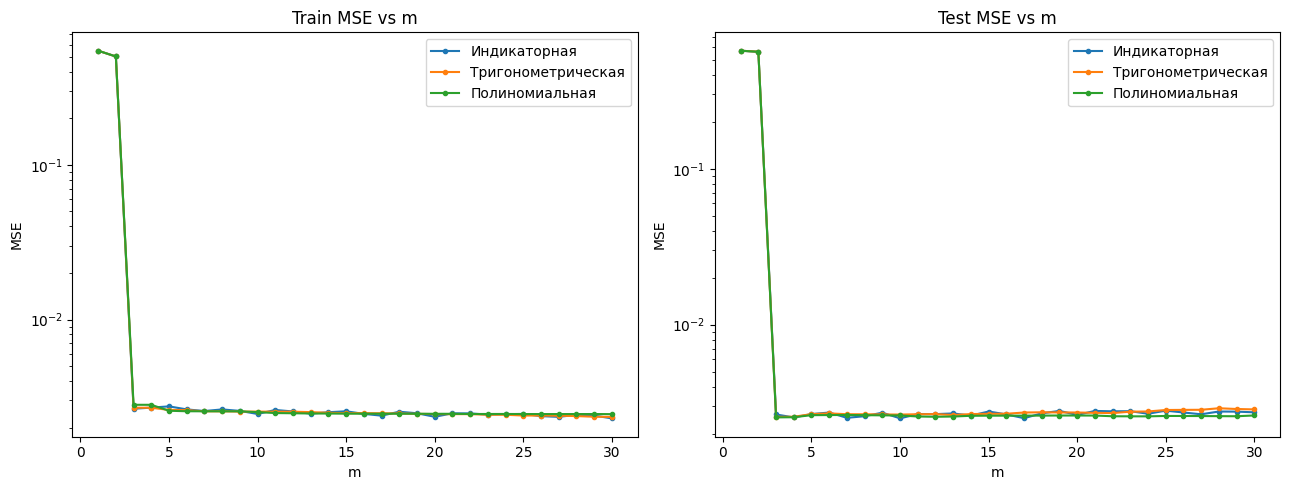

In [24]:
m_range = list(range(1, 31))
train_mse = {'ind': [], 'trig': [], 'poly': []}
test_mse  = {'ind': [], 'trig': [], 'poly': []}

basis_fns = {'ind': indicator_basis, 'trig': trig_basis, 'poly': poly_basis}

for m in m_range:
    for key, fn in basis_fns.items():
        Phi = fn(t, m)
        Z_tr = compute_feature_matrix(X_train, t, Phi)
        Z_te = compute_feature_matrix(X_test,  t, Phi)
        beta = ols_fit(Z_tr, y_train)
        train_mse[key].append(mean_squared_error(y_train, Z_tr @ beta))
        test_mse[key].append(mean_squared_error(y_test,   Z_te @ beta))

colors = {'ind': 'tab:blue', 'trig': 'tab:orange', 'poly': 'tab:green'}
labels = {'ind': 'Индикаторная', 'trig': 'Тригонометрическая', 'poly': 'Полиномиальная'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for key in ['ind', 'trig', 'poly']:
    axes[0].plot(m_range, train_mse[key], marker='o', markersize=3,
                 color=colors[key], label=labels[key])
    axes[1].plot(m_range, test_mse[key],  marker='o', markersize=3,
                 color=colors[key], label=labels[key])

for ax, title in zip(axes, ['Train MSE vs m', 'Test MSE vs m']):
    ax.set_title(title)
    ax.set_xlabel('m')
    ax.set_ylabel('MSE')
    ax.set_yscale('log')
    ax.legend()

plt.tight_layout()
plt.show()

## Задание 7. Гребневая регрессия (Ridge)

### 7a. Вывод формулы решения

Регуляризованный функционал:
$$Q_\lambda(\boldsymbol\beta) = \|\mathbf{y}-\mathbf{Z}\boldsymbol\beta\|^2 + \lambda\|\boldsymbol\beta\|^2$$

Раскрываем и берём градиент:
$$\nabla_{\boldsymbol\beta}Q_\lambda = -2\mathbf{Z}^\top(\mathbf{y}-\mathbf{Z}\boldsymbol\beta) + 2\lambda\boldsymbol\beta = 0$$

$$\implies (\mathbf{Z}^\top\mathbf{Z}+\lambda\mathbf{I})\hat{\boldsymbol\beta}_\lambda = \mathbf{Z}^\top\mathbf{y} \implies \hat{\boldsymbol\beta}_\lambda = (\mathbf{Z}^\top\mathbf{Z}+\lambda\mathbf{I})^{-1}\mathbf{Z}^\top\mathbf{y}$$

### 7b. Влияние на устойчивость

Матрица $\mathbf{Z}^\top\mathbf{Z}+\lambda\mathbf{I}$ **положительно определена** для любого $\lambda>0$ (т.к. $\mathbf{Z}^\top\mathbf{Z}\succeq 0$ и $\lambda\mathbf{I}\succ 0$), следовательно, всегда обратима.

Через SVD $\mathbf{Z}=\mathbf{U}\boldsymbol\Sigma\mathbf{V}^\top$:
$$\hat{\boldsymbol\beta}_\lambda = \sum_j \frac{\sigma_j}{\sigma_j^2+\lambda}\,\mathbf{u}_j^\top\mathbf{y}\,\mathbf{v}_j$$

Малые сингулярные числа $\sigma_j\ll\sqrt{\lambda}$ подавляются, что сокращает дисперсию оценки ценой небольшого смещения (bias-variance tradeoff).

In [25]:
m = 10
Phi_ind_m = indicator_basis(t, m)
Z_tr_m = compute_feature_matrix(X_train, t, Phi_ind_m)
Z_te_m = compute_feature_matrix(X_test,  t, Phi_ind_m)

beta_ols = ols_fit(Z_tr_m, y_train)
ols_tr_mse = mean_squared_error(y_train, Z_tr_m @ beta_ols)
ols_te_mse = mean_squared_error(y_test,  Z_te_m @ beta_ols)

lam_vals = np.logspace(-4, 2, 60)
ridge_tr, ridge_te, beta_norms = [], [], []

for lam in lam_vals:
    br = ridge_fit(Z_tr_m, y_train, lam)
    ridge_tr.append(mean_squared_error(y_train, Z_tr_m @ br))
    ridge_te.append(mean_squared_error(y_test,  Z_te_m @ br))
    beta_norms.append(np.linalg.norm(br[1:]))

best_lam = lam_vals[np.argmin(ridge_te)]
best_te  = min(ridge_te)

print(f"OLS:   Train={ols_tr_mse:.4f}  Test={ols_te_mse:.4f}")
print(f"Ridge: Train={min(ridge_tr):.4f}  Test={best_te:.4f}  lambda*={best_lam:.4f}")

OLS:   Train=0.0024  Test=0.0025
Ridge: Train=0.0024  Test=0.0024  lambda*=0.9249


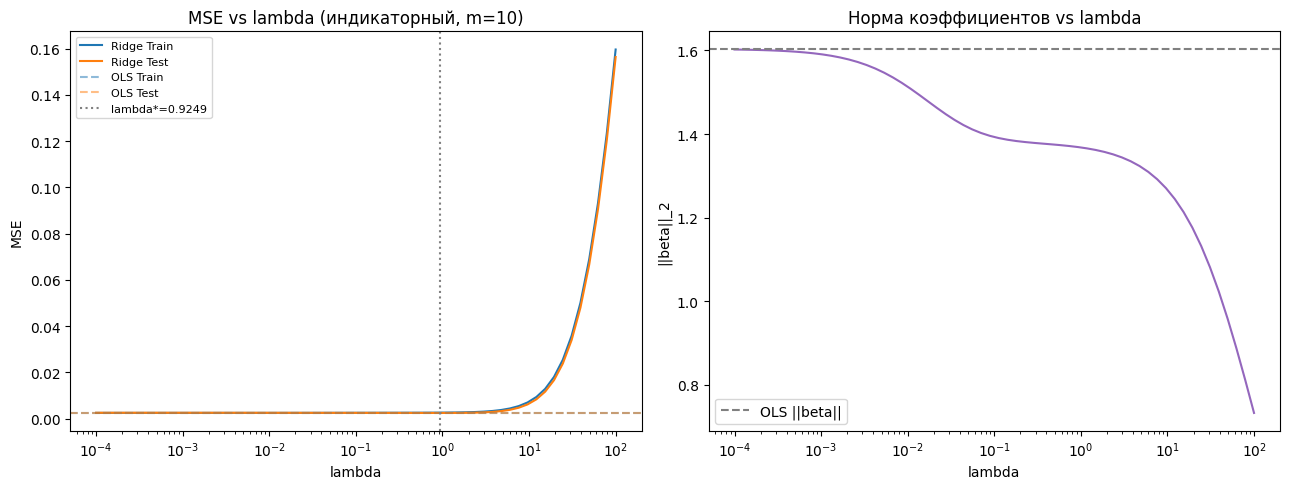

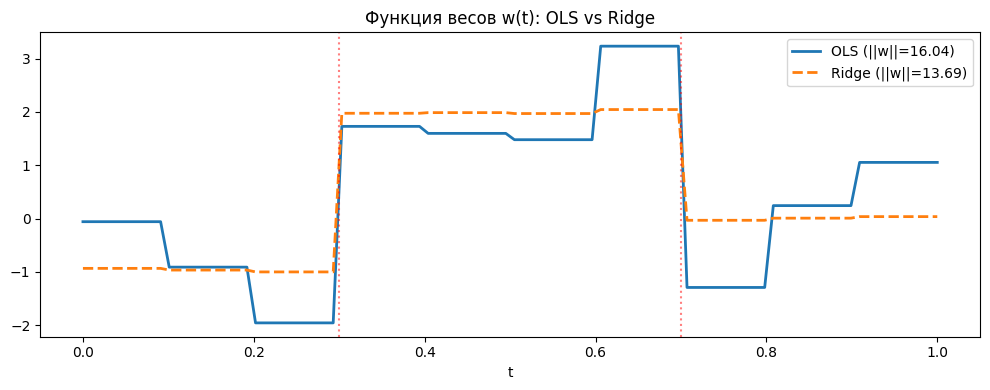

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].semilogx(lam_vals, ridge_tr, label='Ridge Train', color='tab:blue')
axes[0].semilogx(lam_vals, ridge_te, label='Ridge Test',  color='tab:orange')
axes[0].axhline(ols_tr_mse, linestyle='--', color='tab:blue',   alpha=0.5, label='OLS Train')
axes[0].axhline(ols_te_mse, linestyle='--', color='tab:orange', alpha=0.5, label='OLS Test')
axes[0].axvline(best_lam, linestyle=':', color='gray', label=f'lambda*={best_lam:.4f}')
axes[0].set_xlabel('lambda')
axes[0].set_ylabel('MSE')
axes[0].set_title('MSE vs lambda (индикаторный, m=10)')
axes[0].legend(fontsize=8)

axes[1].semilogx(lam_vals, beta_norms, color='tab:purple')
axes[1].axhline(np.linalg.norm(beta_ols[1:]), linestyle='--',
                color='gray', label='OLS ||beta||')
axes[1].set_xlabel('lambda')
axes[1].set_ylabel('||beta||_2')
axes[1].set_title('Норма коэффициентов vs lambda')
axes[1].legend()

plt.tight_layout()
plt.show()

beta_best_ridge = ridge_fit(Z_tr_m, y_train, best_lam)
w_ols   = weight_function(beta_ols,        Phi_ind_m)
w_ridge = weight_function(beta_best_ridge, Phi_ind_m)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t, w_ols,   label=f'OLS (||w||={np.linalg.norm(w_ols):.2f})',   linewidth=2)
ax.plot(t, w_ridge, label=f'Ridge (||w||={np.linalg.norm(w_ridge):.2f})', linewidth=2, linestyle='--')
ax.axvline(0.3, color='r', linestyle=':', alpha=0.5)
ax.axvline(0.7, color='r', linestyle=':', alpha=0.5)
ax.set_title('Функция весов w(t): OLS vs Ridge')
ax.set_xlabel('t')
ax.legend()
plt.tight_layout()
plt.show()

## Задание 8. Устойчивость к шуму и изменению сетки

Исследуем, как растёт ошибка модели при увеличении уровня шума и при изменении плотности сетки.

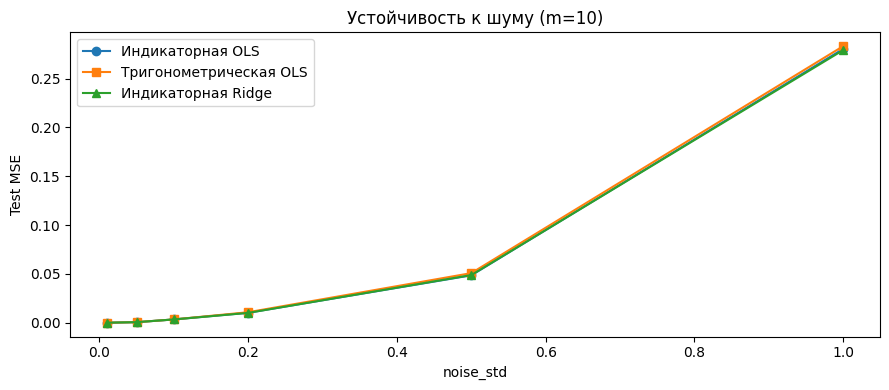

In [27]:
noise_levels = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
noise_results = {'ind_ols': [], 'trig_ols': [], 'ind_ridge': []}
m_fixed = 10

for noise_std in noise_levels:
    X_n, t_n, _ = generate_synthetic_dataset(n_train + n_test, a, b, n_points, noise_std)
    y_n = compute_targets(X_n, t_n, noise_std * 0.5)
    X_tr_n, X_te_n, y_tr_n, y_te_n = train_test_split(X_n, y_n, test_size=n_test, random_state=42)

    Phi_i = indicator_basis(t_n, m_fixed)
    Phi_tr_i = trig_basis(t_n, m_fixed)

    Z_tri = compute_feature_matrix(X_tr_n, t_n, Phi_i)
    Z_tei = compute_feature_matrix(X_te_n, t_n, Phi_i)
    Z_trt = compute_feature_matrix(X_tr_n, t_n, Phi_tr_i)
    Z_tet = compute_feature_matrix(X_te_n, t_n, Phi_tr_i)

    b_ols_i = ols_fit(Z_tri, y_tr_n)
    b_ols_t = ols_fit(Z_trt, y_tr_n)
    b_rid_i = ridge_fit(Z_tri, y_tr_n, best_lam)

    noise_results['ind_ols'].append(mean_squared_error(y_te_n, Z_tei @ b_ols_i))
    noise_results['trig_ols'].append(mean_squared_error(y_te_n, Z_tet @ b_ols_t))
    noise_results['ind_ridge'].append(mean_squared_error(y_te_n, Z_tei @ b_rid_i))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(noise_levels, noise_results['ind_ols'],   marker='o', label='Индикаторная OLS')
ax.plot(noise_levels, noise_results['trig_ols'],  marker='s', label='Тригонометрическая OLS')
ax.plot(noise_levels, noise_results['ind_ridge'], marker='^', label='Индикаторная Ridge')
ax.set_xlabel('noise_std')
ax.set_ylabel('Test MSE')
ax.set_title(f'Устойчивость к шуму (m={m_fixed})')
ax.legend()
plt.tight_layout()
plt.show()

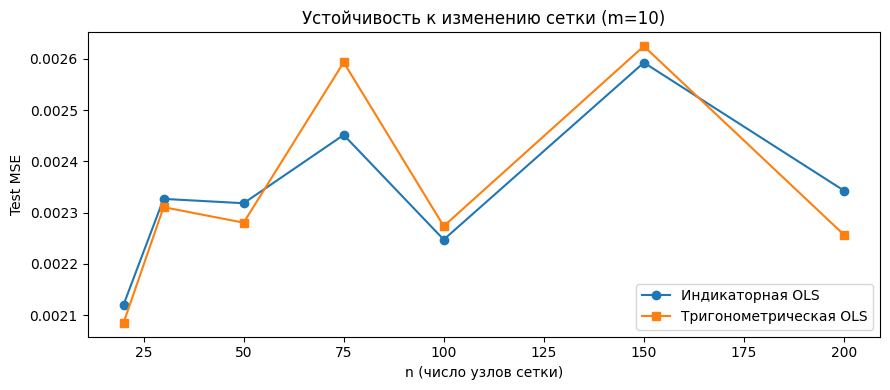

In [28]:
grid_sizes = [20, 30, 50, 75, 100, 150, 200]
grid_results = {'ind': [], 'trig': []}

for n_pts in grid_sizes:
    X_g, t_g, _ = generate_synthetic_dataset(n_train + n_test, a, b, n_pts, noise_std=0.1)
    y_g = compute_targets(X_g, t_g)
    X_tr_g, X_te_g, y_tr_g, y_te_g = train_test_split(X_g, y_g, test_size=n_test, random_state=42)

    for key, fn in [('ind', indicator_basis), ('trig', trig_basis)]:
        Phi = fn(t_g, m_fixed)
        Z_tr = compute_feature_matrix(X_tr_g, t_g, Phi)
        Z_te = compute_feature_matrix(X_te_g, t_g, Phi)
        beta = ols_fit(Z_tr, y_tr_g)
        grid_results[key].append(mean_squared_error(y_te_g, Z_te @ beta))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(grid_sizes, grid_results['ind'],  marker='o', label='Индикаторная OLS')
ax.plot(grid_sizes, grid_results['trig'], marker='s', label='Тригонометрическая OLS')
ax.set_xlabel('n (число узлов сетки)')
ax.set_ylabel('Test MSE')
ax.set_title(f'Устойчивость к изменению сетки (m={m_fixed})')
ax.legend()
plt.tight_layout()
plt.show()

Вывод: ошибка стабилизируется при n >= ~50 — метод устойчив к плотности сетки.